# Experiments conducted on the Riboflavin dataset


In [1]:
#necessary imports
import sparsevb
from sparsevb import svb_fit_linear
from sklearn.model_selection import KFold
from sklearn.linear_model import LassoCV, Lasso, LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import rpy2.robjects as ro

ModuleNotFoundError: No module named 'matplotlib'

In [ ]:
data = fetch_openml(name="riboflavin", as_frame=True)

X = data.data
y = data.target

print(X.shape)
print(y.shape)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

y_train_mean = y_train.mean()
y_train_c = y_train - y_train_mean
y_test_c = y_test - y_train_mean

X = data.data.values.astype(float)
y = data.target.values.astype(float)

(71, 4088)
(71,)


In [ ]:
#alpha tuned once on train split for efficiency, stable across folds in practice
lasso_cv = LassoCV(cv=10, max_iter=10000, random_state=42).fit(X_train_scaled, y_train_c)
best_lasso_alpha = lasso_cv.alpha_
print(f"Best LASSO alpha: {best_lasso_alpha:.6f}")

Best LASSO alpha: 0.006745


In [ ]:
ro.r('set.seed(42)')

kf = KFold(n_splits=10, shuffle=True, random_state=42)

vb_lap_mse, vb_gau_mse, lasso_mse = [], [], []
vb_lap_selected, vb_gau_selected, lasso_selected = [], [], []
gamma_lap_folds, gamma_gau_folds = [], []

for train_idx, val_idx in kf.split(X):
    X_tr, X_val = X[train_idx], X[val_idx]
    y_tr, y_val = y[train_idx], y[val_idx]

    sc = StandardScaler()
    X_tr = sc.fit_transform(X_tr)
    X_val = sc.transform(X_val)

    y_mean = y_tr.mean()
    y_tr_c = y_tr - y_mean
    y_val_c = y_val - y_mean

    res_lap = svb_fit_linear(X_tr, y_tr_c,slab="laplace")
    vb_lap_mse.append(mean_squared_error(y_val_c, X_val @ (res_lap['mu'] * res_lap['gamma'])))
    vb_lap_selected.append((res_lap['gamma'] > 0.5).sum())
    gamma_lap_folds.append(res_lap['gamma'])

    res_gau = svb_fit_linear(X_tr, y_tr_c, slab="gaussian")
    vb_gau_mse.append(mean_squared_error(y_val_c, X_val @ (res_gau['mu'] * res_gau['gamma'])))
    vb_gau_selected.append((res_gau['gamma'] > 0.5).sum())
    gamma_gau_folds.append(res_gau['gamma'])

    lasso = Lasso(alpha=best_lasso_alpha, max_iter=10000)
    lasso.fit(X_tr, y_tr_c)
    lasso_mse.append(mean_squared_error(y_val_c, lasso.predict(X_val)))
    lasso_selected.append((lasso.coef_ != 0).sum())

### 1. MSE

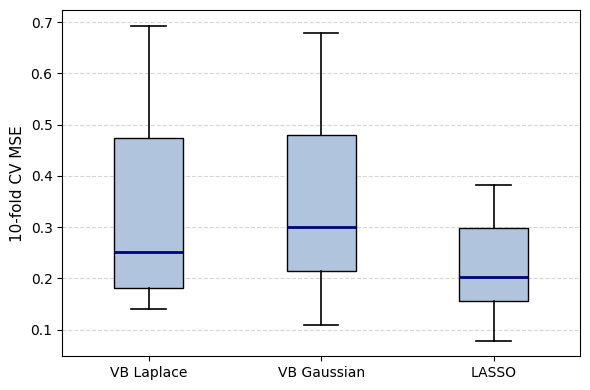

In [ ]:
labels = ["VB Laplace", "VB Gaussian", "LASSO"]

plt.figure(figsize=(6, 4))
plt.boxplot([vb_lap_mse, vb_gau_mse, lasso_mse], tick_labels=labels,
            patch_artist=True, widths=0.4,
            boxprops=dict(facecolor="lightsteelblue"),
            medianprops=dict(color="navy", linewidth=2),
            whiskerprops=dict(linewidth=1.2),
            capprops=dict(linewidth=1.2),
            flierprops=dict(marker='o', markersize=4, linestyle='none'))
plt.ylabel("10-fold CV MSE", fontsize=11)
plt.tick_params(labelsize=10)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("precision.pdf", dpi=150, bbox_inches="tight")
plt.show()

### 2. Model sparsity

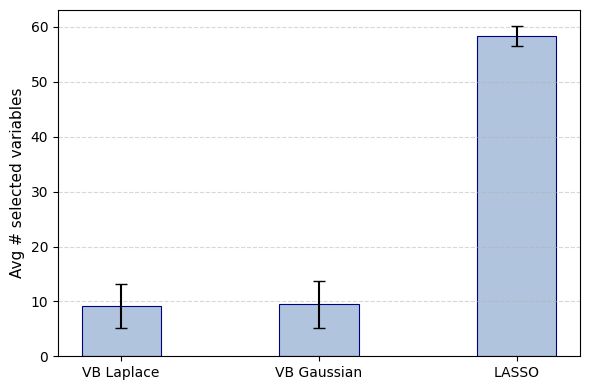

In [ ]:
means = [np.mean(vb_lap_selected), np.mean(vb_gau_selected), np.mean(lasso_selected)]
stds = [np.std(vb_lap_selected), np.std(vb_gau_selected), np.std(lasso_selected)]

plt.figure(figsize=(6, 4))
plt.bar(labels, means, yerr=stds, capsize=4, color="lightsteelblue", edgecolor="navy", linewidth=0.8, width=0.4)
plt.ylabel("Avg # selected variables", fontsize=11)
plt.tick_params(labelsize=10)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("sparsity.pdf", dpi=150, bbox_inches="tight")
plt.show()

### 3. Top genes

In [ ]:
selection_freq_lap = (np.array(gamma_lap_folds) > 0.5).mean(axis=0)
selection_freq_gau = (np.array(gamma_gau_folds) > 0.5).mean(axis=0)

gamma_lap_matrix = np.array(gamma_lap_folds)
gamma_gau_matrix = np.array(gamma_gau_folds)

mean_gamma_lap = gamma_lap_matrix.mean(axis=0)
mean_gamma_gau = gamma_gau_matrix.mean(axis=0)

vb_lap_rank = np.argsort(mean_gamma_lap)[::-1]
vb_gau_rank = np.argsort(mean_gamma_gau)[::-1]

lasso_full = Lasso(alpha=best_lasso_alpha, max_iter=10000).fit(X_train_scaled, y_train_c)
lasso_rank = np.argsort(np.abs(lasso_full.coef_))[::-1]

In [ ]:
k_values = list(range(1, 51))
kf2 = KFold(n_splits=10, shuffle=True, random_state=42)

vb_lap_mse_k = np.zeros(len(k_values))
vb_gau_mse_k = np.zeros(len(k_values))
lasso_mse_k  = np.zeros(len(k_values))

for train_idx, val_idx in kf2.split(X):
    X_tr, X_val = X[train_idx], X[val_idx]
    y_tr, y_val = y[train_idx], y[val_idx]

    sc = StandardScaler()
    X_tr  = sc.fit_transform(X_tr)
    X_val = sc.transform(X_val)

    y_mean  = y_tr.mean()
    y_tr_c  = y_tr - y_mean
    y_val_c = y_val - y_mean

    for j, k in enumerate(k_values):
        lr = LinearRegression()

        lr.fit(X_tr[:, vb_lap_rank[:k]], y_tr_c)
        vb_lap_mse_k[j] += mean_squared_error(y_val_c, lr.predict(X_val[:, vb_lap_rank[:k]]))

        lr.fit(X_tr[:, vb_gau_rank[:k]], y_tr_c)
        vb_gau_mse_k[j] += mean_squared_error(y_val_c, lr.predict(X_val[:, vb_gau_rank[:k]]))

        lr.fit(X_tr[:, lasso_rank[:k]], y_tr_c)
        lasso_mse_k[j] += mean_squared_error(y_val_c, lr.predict(X_val[:, lasso_rank[:k]]))

vb_lap_mse_k /= 10
vb_gau_mse_k /= 10
lasso_mse_k  /= 10

print(f"Best VB Laplace  MSE: {min(vb_lap_mse_k):.4f} at k={np.argmin(vb_lap_mse_k)+1}")
print(f"Best VB Gaussian MSE: {min(vb_gau_mse_k):.4f} at k={np.argmin(vb_gau_mse_k)+1}")
print(f"Best LASSO MSE: {min(lasso_mse_k):.4f} at k={np.argmin(lasso_mse_k)+1}")

Best VB Laplace  MSE: 0.0763 at k=38
Best VB Gaussian MSE: 0.0820 at k=25
Best LASSO MSE: 0.0971 at k=25


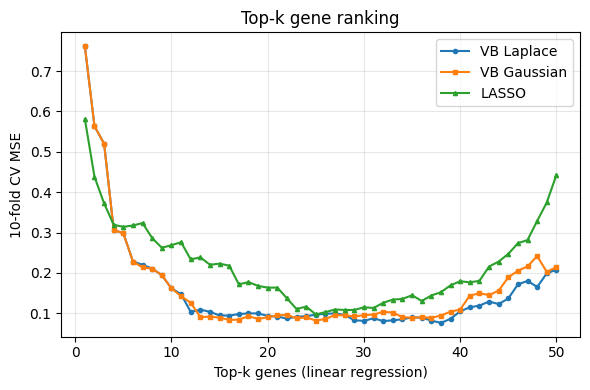

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(k_values, vb_lap_mse_k, label="VB Laplace", marker='o', markersize=3)
plt.plot(k_values, vb_gau_mse_k, label="VB Gaussian", marker='s', markersize=3)
plt.plot(k_values, lasso_mse_k, label="LASSO", marker='^', markersize=3)
plt.xlabel("Top-k genes (linear regression)")
plt.ylabel("10-fold CV MSE")
plt.title("Top-k gene ranking")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("topk.pdf", dpi=150, bbox_inches="tight")
plt.show()

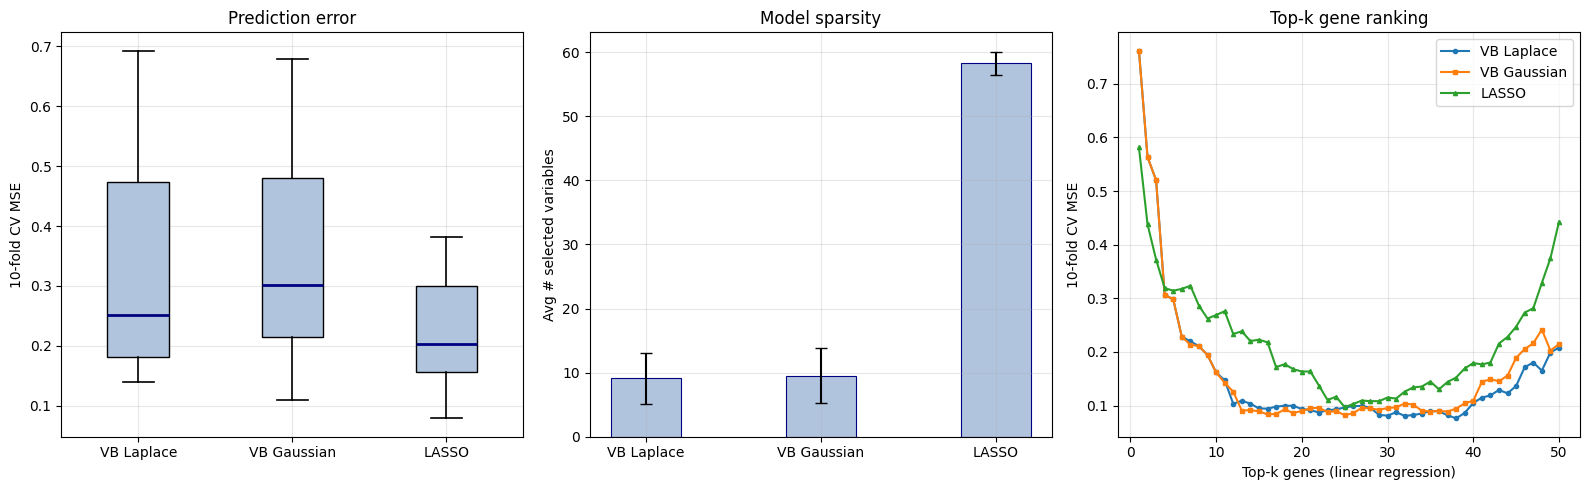

In [ ]:
#cleaner all-in-one figure for the paper
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].boxplot([vb_lap_mse, vb_gau_mse, lasso_mse], tick_labels=labels,
                patch_artist=True, widths=0.4,
                boxprops=dict(facecolor="lightsteelblue"),
                medianprops=dict(color="navy", linewidth=2),
                whiskerprops=dict(linewidth=1.2),
                capprops=dict(linewidth=1.2),
                flierprops=dict(marker='o', markersize=4, linestyle='none'))
axes[0].set_ylabel("10-fold CV MSE")
axes[0].set_title("Prediction error")
axes[0].grid(True, alpha=0.3)

axes[1].bar(labels, means, yerr=stds, capsize=4, color="lightsteelblue",
            edgecolor="navy", linewidth=0.8, width=0.4)
axes[1].set_ylabel("Avg # selected variables")
axes[1].set_title("Model sparsity")
axes[1].grid(True, alpha=0.3)

axes[2].plot(k_values, vb_lap_mse_k, label="VB Laplace", marker='o', markersize=3)
axes[2].plot(k_values, vb_gau_mse_k, label="VB Gaussian", marker='s', markersize=3)
axes[2].plot(k_values, lasso_mse_k, label="LASSO", marker='^', markersize=3)
axes[2].set_xlabel("Top-k genes (linear regression)")
axes[2].set_ylabel("10-fold CV MSE")
axes[2].set_title("Top-k gene ranking")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("riboflavin_experiments.pdf", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
gene_names = data.feature_names
target_genes = ["YXLD_at", "LYSC_at", "YOAB_at"]


lasso_coef_folds = []
for tr, _ in KFold(n_splits=10, shuffle=True, random_state=42).split(X):
    sc_fold = StandardScaler()
    X_tr_scaled = sc_fold.fit_transform(X[tr])
    y_tr_c = y[tr] - y[tr].mean()
    coef = Lasso(alpha=best_lasso_alpha, max_iter=10000).fit(X_tr_scaled, y_tr_c).coef_
    lasso_coef_folds.append(coef)

mean_lasso_coef = np.mean(np.abs(lasso_coef_folds), axis=0)
lasso_rank = np.argsort(mean_lasso_coef)[::-1]

print(f"{'Gene':<15} {'VB Lap rank':>12} {'VB Lap γ':>10} {'VB Lap freq':>12} {'VB Gau rank':>12}{'VB Gau γ':>10} {'VB Gau freq':>12} {'LASSO rank':>12} {'LASSO sel':>12}")
print("-" * 120)

for gene in target_genes:
    idx = gene_names.index(gene)

    lap_r = np.where(vb_lap_rank == idx)[0][0] + 1
    gau_r = np.where(vb_gau_rank == idx)[0][0] + 1
    lasso_r = np.where(lasso_rank == idx)[0][0] + 1

    lap_freq = selection_freq_lap[idx]
    gau_freq = selection_freq_gau[idx]
    lasso_sel = np.mean([np.abs(coef[idx]) != 0 for coef in lasso_coef_folds])

    print(f"{gene:<15} {lap_r:>12} {mean_gamma_lap[idx]:>10.3f} {lap_freq:>12.0%} {gau_r:>12} {mean_gamma_gau[idx]:>10.3f} {gau_freq:>12.0%} {lasso_r:>12} {lasso_sel:>12.0%}")

Gene             VB Lap rank   VB Lap γ  VB Lap freq  VB Gau rank  VB Gau γ  VB Gau freq   LASSO rank    LASSO sel
------------------------------------------------------------------------------------------------------------------------
YXLD_at                    7      0.400          40%            8      0.400          40%            2          90%
LYSC_at                    3      0.600          60%            3      0.600          60%            7          90%
YOAB_at                    2      0.602          60%            2      0.602          60%            1         100%


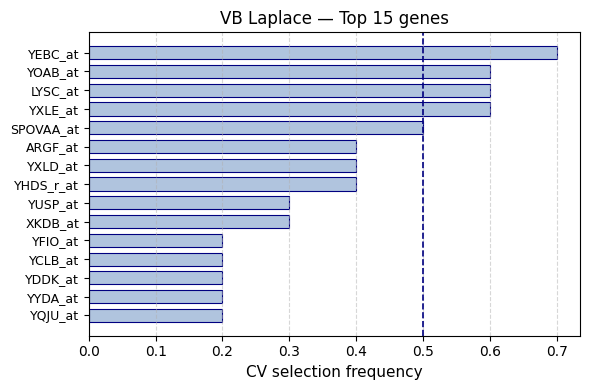

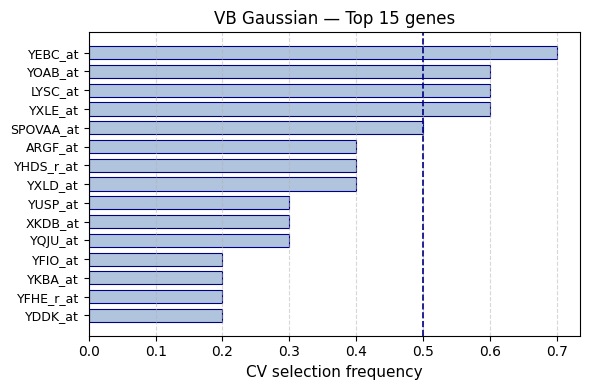

In [ ]:
top15_lap = vb_lap_rank[:15]
top15_gau = vb_gau_rank[:15]

plt.figure(figsize=(6, 4))
plt.barh(range(15)[::-1], selection_freq_lap[top15_lap], color="lightsteelblue", edgecolor="navy", linewidth=0.8, height=0.7)
plt.yticks(range(15)[::-1], [gene_names[i][:25] for i in top15_lap], fontsize=9)
plt.axvline(0.5, color="navy", linestyle="--", linewidth=1.2)
plt.xlabel("CV selection frequency", fontsize=11)
plt.title("VB Laplace — Top 15 genes", fontsize=12)
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.barh(range(15)[::-1], selection_freq_gau[top15_gau], color="lightsteelblue", edgecolor="navy", linewidth=0.8, height=0.7)
plt.yticks(range(15)[::-1], [gene_names[i][:25] for i in top15_gau], fontsize=9)
plt.axvline(0.5, color="navy", linestyle="--", linewidth=1.2)
plt.xlabel("CV selection frequency", fontsize=11)
plt.title("VB Gaussian — Top 15 genes", fontsize=12)
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()